# Steering proof-of-concept: turning the NCAP swimmer left and right

The NCAP swimmer circuit (Bhattasali, Zador & Engel 2022) is a *C. elegans*-derived
network that swims on its own. The paper models **steering** as two extra excitatory
inputs to the first head B-neurons: a right-turn signal `r` (to the dorsal side) and a
left-turn signal `l` (to the ventral side).

This notebook is a minimal test that those turn inputs actually work: a **hardcoded
reflex** (`make_turn_reflex`, in `src/macrocircuits/reflex_steering.py`) that ignores
all sensing and just holds the turn signal to one side every step. **No training** --
the circuit is used at its paper initialization (all weights = 1), which already swims.

- `turn_left`  -> drives `l` -> the body pivots one way.
- `turn_right` -> drives `r` -> the body pivots the other way.

We hold the turn signal hard enough that the worm **pivots in place** -- it spins on the
spot rather than swimming off in a wide arc. Each is rolled out on the plain `swim` task,
and we show (1) an overhead video of the worm and (2) the path its head traced (a tight
loop as it spins), so the turn direction is unmistakable.

In [1]:
# Setup. This notebook only orchestrates; the circuit and the turn reflex live in the
# `macrocircuits` package under src/.
%matplotlib inline
import sys
from pathlib import Path

SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import matplotlib.pyplot as plt

# ensure_tonic() clones neuromatch/tonic next to this notebook and puts it on the path;
# it must run before importing anything that pulls in tonic (models below). See
# src/macrocircuits/tonic_setup.py for why tonic isn't a pip install.
from macrocircuits import ensure_tonic
ensure_tonic()

import torch
import tonic
import tonic.torch
from dm_control.mujoco import engine

from macrocircuits.models import ppo_swimmer_model
from macrocircuits.reflex_steering import make_turn_reflex
from macrocircuits.video import display_video

N_JOINTS = 5      # 6-link swimmer
TURN_STRENGTH = 0.75  # constant turn signal in [0,1]. ~0.75 makes the worm pivot on the
                      # spot (turn in place -- a tight spin); ~0.5 traces a wide arc
                      # instead; >=0.8 overpowers the head oscillator and the spin
                      # destabilises (it can even flip direction), so 0.75 is the sweet
                      # spot for a clean, tight, correctly-signed in-place turn.
print('ready')

ready


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Rollout helper

Build an NCAP swimmer whose steering is the hardcoded turn reflex, run it
deterministically on `swim`, and record both an overhead video frame and the head's
world position at every step. Nothing is trained or loaded -- the model is fresh.

In [2]:
def _get_physics(env):
    """Walk tonic's gym-wrapper chain down to the dm_control Physics."""
    while env is not None:
        if hasattr(env, 'physics'):
            return env.physics
        inner = getattr(env, 'environment', None)
        if inner is not None and hasattr(inner, 'physics'):
            return inner.physics
        env = getattr(env, 'env', None)
    raise RuntimeError('no physics found in environment chain')


def _overhead_frame(physics, distance=1.8):
    """A fresh straight-down camera fixed on the arena origin (where the worm starts), so
    the worm is seen pivoting in one spot rather than kept centered in view. Built per
    frame on purpose: reusing one engine.Camera silently freezes on its first pose."""
    cam = engine.Camera(physics, height=480, width=640, camera_id=-1)
    rc = cam._render_camera
    rc.lookat[:] = [0.0, 0.0, 0.0]
    rc.distance = distance
    rc.azimuth = 90
    rc.elevation = -90  # top-down; the camera is fixed, so any rotation of the body on
                        # screen is a real change of heading, and it staying put shows
                        # the turn is in place.
    frame = cam.render()
    cam._scene.free()
    return frame


def turn_rollout(direction, strength=TURN_STRENGTH, steps=600, seed=0):
    """Roll out a fresh NCAP swimmer steered by make_turn_reflex(direction). Returns
    (frames, xs, ys): overhead frames and the head's world x/y at each step."""
    torch.manual_seed(seed)
    controller = make_turn_reflex(N_JOINTS, direction=direction, strength=strength)
    model = ppo_swimmer_model(n_joints=N_JOINTS, critic_sizes=(256, 256),
                              action_noise=0.1, controller=controller)
    env = tonic.environments.ControlSuite('swimmer-swim', time_feature=True)
    physics = _get_physics(env)
    actor = model.actor
    actor.initialize(observation_space=env.observation_space,
                     action_space=env.action_space)

    obs = env.reset()
    frames, xs, ys = [], [], []
    for _ in range(steps):
        with torch.no_grad():
            out = actor(torch.as_tensor(obs[None], dtype=torch.float32))
            action = (out.loc if hasattr(out, 'loc') else out).numpy()[0]  # deterministic
        obs, _, done, _ = env.step(action)
        frames.append(_overhead_frame(physics))
        head = physics.named.data.xpos['head'][:2]
        xs.append(float(head[0])); ys.append(float(head[1]))
        if done:
            obs = env.reset()
    return frames, np.array(xs), np.array(ys)


def _smooth(a, w=21):
    """Moving average, to read the arc's heading past the gait's stroke-by-stroke wobble."""
    if len(a) < w:
        return a
    k = np.ones(w) / w
    return np.convolve(a, k, mode='valid')


def net_turn_degrees(xs, ys):
    """Net change in travel direction along the smoothed path (deg). +ve left, -ve right."""
    xs, ys = _smooth(xs), _smooth(ys)
    d = np.diff(np.c_[xs, ys], axis=0)
    keep = np.hypot(d[:, 0], d[:, 1]) > 1e-4
    ang = np.unwrap(np.arctan2(d[keep, 1], d[keep, 0]))
    return float(np.degrees(ang[-1] - ang[0])) if len(ang) > 1 else 0.0


def plot_path(xs, ys, title, ax=None):
    """Top-down head path, colored by time, with start/end and a heading arrow."""
    ax = ax or plt.subplots(figsize=(5, 5))[1]
    pts = np.c_[xs, ys]
    ax.scatter(xs, ys, c=np.arange(len(xs)), cmap='viridis', s=6)
    ax.plot(xs, ys, color='0.6', lw=0.6, zorder=0)
    ax.scatter([xs[0]], [ys[0]], c='lime', s=90, ec='k', zorder=5, label='start')
    ax.scatter([xs[-1]], [ys[-1]], c='red', s=90, ec='k', zorder=5, label='end')
    d = pts[-1] - pts[-11]
    ax.annotate('', xy=pts[-1] + d, xytext=pts[-1],
                arrowprops=dict(arrowstyle='-|>', color='red', lw=2))
    ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(loc='best')
    ax.set_xlabel('world x'); ax.set_ylabel('world y'); ax.set_title(title)
    return ax

print('helpers defined')

helpers defined


## Turn **left**

`make_turn_reflex(..., direction='left')` drives NCAP's left-turn input `l` every step.

In [3]:
frames_L, xL, yL = turn_rollout('left')
print(f'net change of heading: {net_turn_degrees(xL, yL):+.0f} deg  (positive = turned left)')
display_video(frames_L, 'output_videos/turn_left.mp4', fps=40)

C:\Users\lukav\OneDrive\Documents\CogSci\projects\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


net change of heading: +392 deg  (positive = turned left)


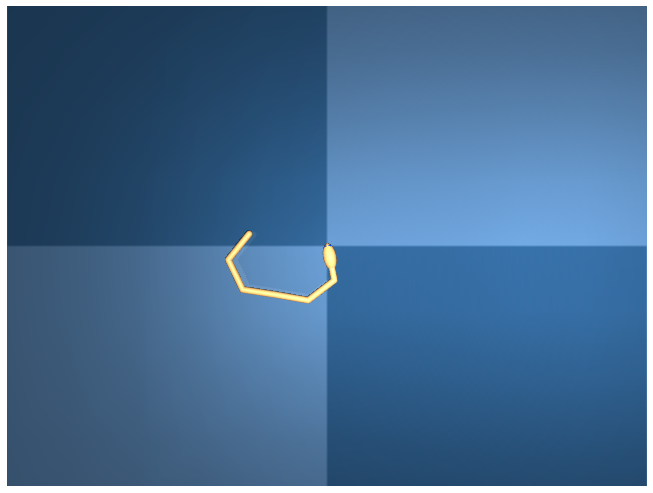

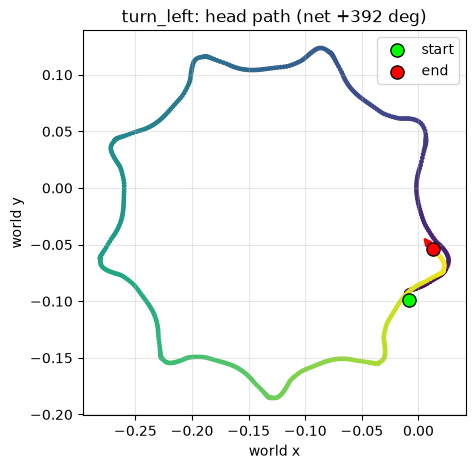

In [4]:
plot_path(xL, yL, f'turn_left: head path (net {net_turn_degrees(xL, yL):+.0f} deg)')
plt.show()

## Turn **right**

`make_turn_reflex(..., direction='right')` drives NCAP's right-turn input `r` every step
-- the same circuit, the opposite side.

In [5]:
frames_R, xR, yR = turn_rollout('right')
print(f'net change of heading: {net_turn_degrees(xR, yR):+.0f} deg  (negative = turned right)')
display_video(frames_R, 'output_videos/turn_right.mp4', fps=40)

C:\Users\lukav\OneDrive\Documents\CogSci\projects\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


net change of heading: -265 deg  (negative = turned right)


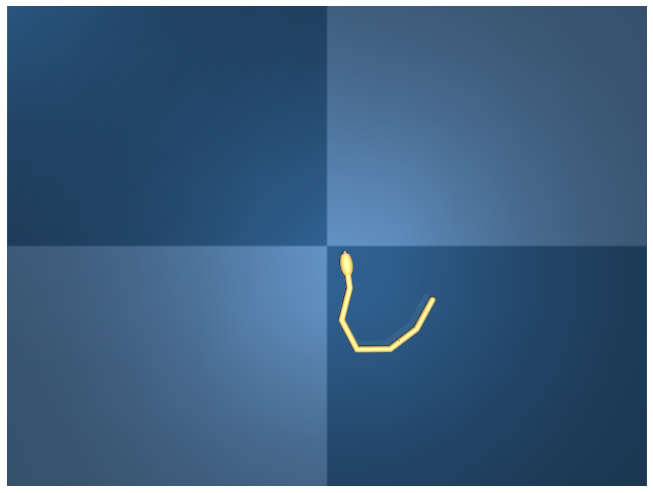

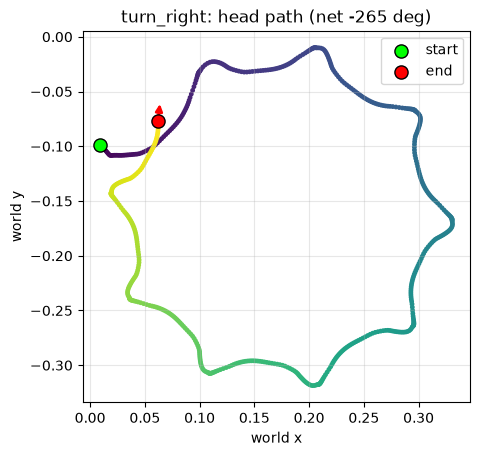

In [6]:
plot_path(xR, yR, f'turn_right: head path (net {net_turn_degrees(xR, yR):+.0f} deg)')
plt.show()

## Side by side

The same untrained circuit, the only difference being which hardcoded turn input is
held on: the worm pivots in place, and the two head loops wind in opposite directions.

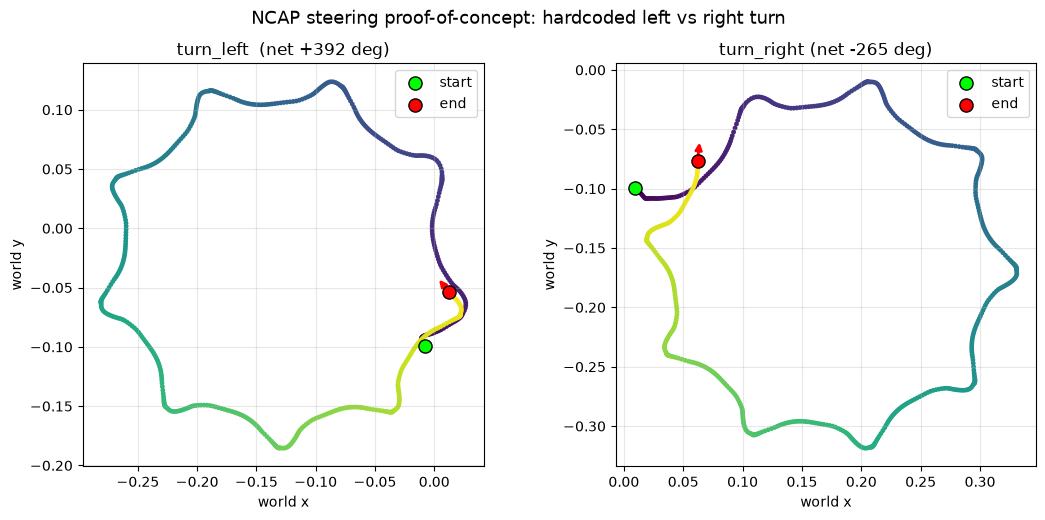

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
plot_path(xL, yL, f'turn_left  (net {net_turn_degrees(xL, yL):+.0f} deg)', ax=axes[0])
plot_path(xR, yR, f'turn_right (net {net_turn_degrees(xR, yR):+.0f} deg)', ax=axes[1])
fig.suptitle('NCAP steering proof-of-concept: hardcoded left vs right turn', fontsize=13)
fig.tight_layout()
plt.show()